In [37]:
import os
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Homography mapping of Top → Side cameras with RANSAC
Let's estimate a **planar mapping** between the Top camera and each Side camera using a **homography**. A homography is a 3×3 projective transform \(H\) that maps 2D points on the same physical plane between two camera views:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} \sim
H \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$

#### Why RANSAC?
SLEAP labelling occasionally contain outliers (mislocalized corners, brief occlusions, motion blur). Fitting \(H\) directly to all correspondences can fail. **RANSAC** makes the fit robust by repeatedly:
1. Sampling a minimal set of 4 point correspondences,
2. Fitting a candidate homography,
3. Counting **inliers** (pairs whose reprojection error is below a pixel threshold),
4. Keeping the model with the most inliers, then refitting using all inliers.

#### Inputs to RANSAC
We use matched high-quality frames where **all 4 card corners** are present in both cameras and have confidence ≥ a chosen threshold (used 0.85 confidence). For each camera pair we build:
- `top_pts`: shape `(N, 4, 2)`
- `side_pts`: shape `(N, 4, 2)`
These are reshaped into a single list of point pairs `(4N, 2)` for homography estimation.

#### Output
For each Side camera we obtain a homography \(H_{top\rightarrow side}\) plus an inlier mask and basic fit diagnostics (inlier count, reprojection error).

#### Metadata

In [45]:
experiment = "abcEphysPilot01"
arena = "AEON3"
session = "2026-04-14T141851Z_calibrateBeforeAprilExperiments"
chunk = "2026-04-14T14-00-00"

OUT_DIR = Path(f"/Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/{experiment}")
MAP_PATH = OUT_DIR / "mapping_top_to_sides_minScore0.85.npz"
assert MAP_PATH.exists(), f"Missing: {MAP_PATH}"

### Homography params

In [46]:
ransac_reproj_threshold_px = 5.0   # typical: 2-10 px; increase if detections are noisy
ransac_confidence = 0.995
ransac_max_iters = 5000

# Cameras expected inside the saved npz (based on your earlier naming convention)
side_cameras = ["CameraNorth", "CameraSouth", "CameraEast", "CameraWest"]

#### Load .npz file with card mappings

In [47]:
z = np.load(MAP_PATH)

# Quick peek
keys = sorted(list(z.keys()))
print("Keys in npz (first 20):")
print(keys[:20])
print("\nTotal keys:", len(keys))

Keys in npz (first 20):
['CameraEast__frames', 'CameraEast__side_pts', 'CameraEast__top_pts', 'CameraNorth__frames', 'CameraNorth__side_pts', 'CameraNorth__top_pts', 'CameraSouth__frames', 'CameraSouth__side_pts', 'CameraSouth__top_pts', 'CameraWest__frames', 'CameraWest__side_pts', 'CameraWest__top_pts']

Total keys: 12


## Helper fun

In [48]:
def stack_corner_points(arr: np.ndarray) -> np.ndarray:
    """
    Convert (N,4,2) -> (4N,2).
    Each frame contributes 4 corner correspondences.
    """
    re_arr = np.asarray(arr, dtype=np.float32)
    assert re_arr.ndim == 3 and re_arr.shape[1:] == (4, 2), f"Expected (N,4,2), got {re_arr.shape}" # check if for sure that shape
    return re_arr.reshape(-1, 2)

def apply_homography(H: np.ndarray, xy: np.ndarray) -> np.ndarray:
    """
    Apply 3x3 homography H to points xy of shape (M,2).
    Returns projected points (M,2).
    """
    xy = np.asarray(xy, dtype=np.float64)
    ones = np.ones((xy.shape[0], 1), dtype=np.float64)
    X = np.concatenate([xy, ones], axis=1)  # (M,3) so each row is [x, y, 1]
    Y = (H @ X.T).T                         # X.T is (3, M), and we apply the H matrix to every point, then return [u, v, w]
    y = Y[:, :2] / Y[:, 2:3]                # obtain [u, v] and [w] and divide by w: dehomogenization
    return y

def reprojection_errors_px(H: np.ndarray, src_xy: np.ndarray, dst_xy: np.ndarray) -> np.ndarray:
    """
    Pixel reprojection error per correspondence -> Euclidean distance between projections
    """
    pred = apply_homography(H, src_xy) # this is the predicted dst_xy
    return np.linalg.norm(pred - np.asarray(dst_xy, dtype=np.float64), axis=1)

## RANSAC

In [49]:
rows = []
H_by_cam = {}
inliers_by_cam = {}

for cam in side_cameras:
    frames_key = f"{cam}__frames"
    top_key = f"{cam}__top_pts"
    side_key = f"{cam}__side_pts"

    if frames_key not in z or top_key not in z or side_key not in z: # check file content for the camera of intrest 
        print(f"Skipping {cam}: missing keys in npz.")
        continue
    
    # unpack data
    frames = z[frames_key]
    top_pts = z[top_key]     # (N,4,2)
    side_pts = z[side_key]   # (N,4,2)
    
    src = stack_corner_points(top_pts)   # Top points, shape (4N,2)
    dst = stack_corner_points(side_pts)  # Side points, shape (4N,2)

    if src.shape[0] < 4:  # for very low point amounts check
        print(f"Skipping {cam}: not enough correspondences ({src.shape[0]}).")
        continue

    # Fit homography with RANSAC
    H, inlier_mask = cv2.findHomography(
        src, dst,
        method=cv2.RANSAC,
        ransacReprojThreshold=ransac_reproj_threshold_px,
        maxIters=ransac_max_iters,
        confidence=ransac_confidence,
    )

    if H is None or inlier_mask is None:
        print(f"Failed to fit homography for {cam}.")
        continue

    inlier_mask = inlier_mask.ravel().astype(bool)
    errs = reprojection_errors_px(H, src, dst)

    n_total = src.shape[0]
    n_in = int(inlier_mask.sum())
    frac_in = n_in / n_total if n_total else np.nan

    rows.append({
        "camera": cam,
        "n_frames_used": int(top_pts.shape[0]),
        "n_correspondences": int(n_total),
        "n_inliers": n_in,
        "inlier_frac": frac_in,
        "median_err_px_all": float(np.median(errs)),
        "median_err_px_inliers": float(np.median(errs[inlier_mask])) if n_in else np.nan,
        "mean_err_px_inliers": float(np.mean(errs[inlier_mask])) if n_in else np.nan,
        "ransac_thresh_px": float(ransac_reproj_threshold_px),
    })

    H_by_cam[cam] = H
    inliers_by_cam[cam] = inlier_mask

summary_df = pd.DataFrame(rows).sort_values("camera")
display(summary_df)

,camera,n_frames_used,n_correspondences,n_inliers,inlier_frac,median_err_px_all,median_err_px_inliers,mean_err_px_inliers,ransac_thresh_px
2,CameraEast,2281,9124,3165,0.346887,9.222850,2.809144,2.797107,5.0
0,CameraNorth,1897,7588,3387,0.446363,5.622073,2.372335,2.571399,5.0
1,CameraSouth,1039,4156,2277,0.547883,4.280393,2.493302,2.477923,5.0
3,CameraWest,1767,7068,2876,0.406904,6.411124,2.657158,2.735012,5.0


## Reprojection error sanity check

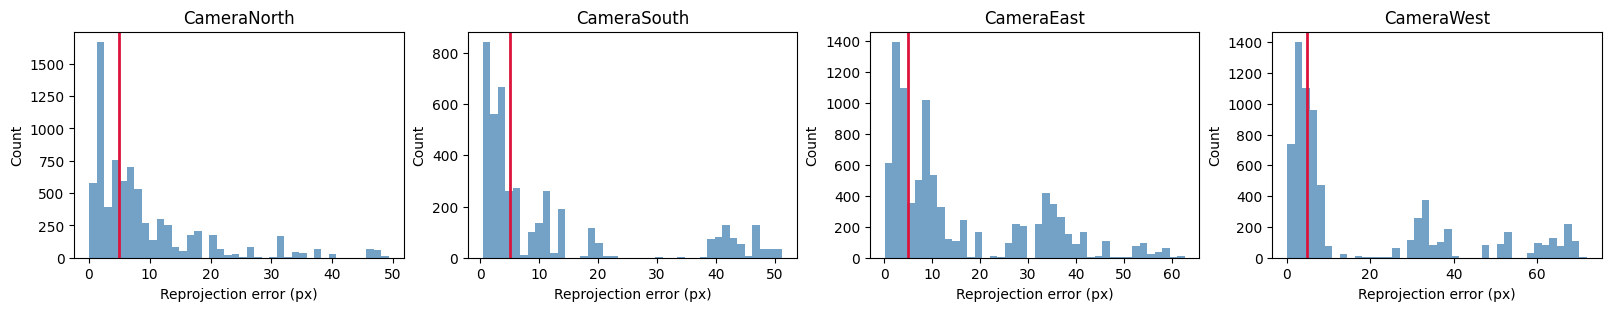

In [50]:
fig, axes = plt.subplots(1, len(H_by_cam), figsize=(4 * len(H_by_cam), 3), constrained_layout=True)
if len(H_by_cam) == 1:
    axes = [axes]

for ax, (cam, H) in zip(axes, H_by_cam.items()):
    src = stack_corner_points(z[f"{cam}__top_pts"])
    dst = stack_corner_points(z[f"{cam}__side_pts"])
    inlier_mask = inliers_by_cam[cam]
    errs = reprojection_errors_px(H, src, dst)

    ax.hist(errs, bins=40, alpha=0.75, color="steelblue")
    ax.axvline(ransac_reproj_threshold_px, color="crimson", linewidth=2, label="RANSAC thresh")
    ax.set_title(cam)
    ax.set_xlabel("Reprojection error (px)")
    ax.set_ylabel("Count")

plt.show()

#### **What the number means:** for each matched corner correspondence, you take the **Top** corner point, map it into the **Side** image using the fitted homography **H**, and measure the pixel distance to where SLEAP actually predicted that corner in the Side image -> the lower the better

## Save homography matrices

In [ ]:
H_save_path = OUT_DIR / f"homographies_top_to_sides_ransac_thresh{ransac_reproj_threshold_px:.1f}px.npz"
np.savez_compressed(
    H_save_path,
    **{f"{cam}__H_top_to_side": H for cam, H in H_by_cam.items()}
)
print("Saved homographies:", H_save_path)

# Save the summary table
summary_csv_path = OUT_DIR / f"homography_fit_summary_thresh{ransac_reproj_threshold_px:.1f}px.csv"
summary_df.to_csv(summary_csv_path, index=False)
print("Saved fit summary:", summary_csv_path)

NameError: name 'out_dir' is not defined

## Visual sanity check

In [51]:
# helper functions for frame transformation
def read_frame(video_path: str | Path, frame_idx: int) -> np.ndarray:
    """Read one BGR frame from a video at frame_idx."""
    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise RuntimeError(f"Could not read frame {frame_idx} from: {video_path}")
    return frame  # BGR

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def overlay_side_on_top(top_bgr: np.ndarray, side_bgr: np.ndarray, H_top_to_side: np.ndarray, alpha: float):
    """
    Returns:
      - overlay_rgb: Top + warped(Side) blended in Top coordinates
      - warped_side_rgb: Side warped into Top coordinates
      - H_side_to_top: inverse homography used for warping
    """
    H_side_to_top = np.linalg.inv(H_top_to_side)
    top_h, top_w = top_bgr.shape[:2]
    warped_side_bgr = cv2.warpPerspective(side_bgr, H_side_to_top, (top_w, top_h))
    top_rgb = bgr_to_rgb(top_bgr)
    side_rgb = bgr_to_rgb(side_bgr)
    warped_side_rgb = bgr_to_rgb(warped_side_bgr)
    overlay_rgb = cv2.addWeighted(top_rgb, 1 - alpha, warped_side_rgb, alpha, 0)
    return overlay_rgb, warped_side_rgb, top_rgb, side_rgb, H_side_to_top


In [52]:
# file retrieval
def build_video_path(raw_video_root: Path, arena: str, experiment: str, session: str, chunk: str, camera: str) -> Path:
    return raw_video_root / arena / experiment / session / camera / f"{camera}_{chunk}.avi"

def load_npz_pair(out_dir: Path, corr_name: str, H_glob: str):
    corr_npz = out_dir / corr_name
    H_npz = next(out_dir.glob(H_glob))
    z_corr = np.load(corr_npz)
    z_H = np.load(H_npz)
    print("Loaded correspondences:", corr_npz)
    print("Loaded homographies:", H_npz)
    return z_corr, z_H, corr_npz, H_npz

In [53]:
# plotting helper functions
def draw_corner_viz(overlay_rgb: np.ndarray, top4_xy: np.ndarray, side4_xy_warped: np.ndarray):
    """
    Draws:
      - green circles: Top corners
      - red circles: Side corners warped into Top coords
    """
    viz = overlay_rgb.copy()
    for (x, y) in top4_xy:
        cv2.circle(viz, (int(x), int(y)), 6, (0, 255, 0), -1)
    for (x, y) in side4_xy_warped:
        cv2.circle(viz, (int(x), int(y)), 6, (255, 0, 0), -1)
    return viz

def show_triptych(top_rgb, side_rgb, overlay_rgb, camera_side: str, frame_idx: int):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"CameraTop (frame {frame_idx})")
    plt.imshow(top_rgb)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title(f"{camera_side} raw (frame {frame_idx})")
    plt.imshow(side_rgb)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Overlay (Top + warped Side)")
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.show()

def show_corner_overlay(viz_rgb, camera_side: str):
    plt.figure(figsize=(7, 6))
    plt.title(f"Overlay + corners for {camera_side}\n(green=Top, red=Side warped)")
    plt.imshow(viz_rgb)
    plt.axis("off")
    plt.show()

In [54]:
raw_video_root = Path("/Volumes/aeon/aeon/data/raw")  # on ceph
alpha = 0.55 # transparency for overlay

# Load mapping products
z_corr, z_H, corr_npz, H_npz = load_npz_pair(
    OUT_DIR,
    corr_name="mapping_top_to_sides_minScore0.85.npz",
    H_glob="homographies_top_to_sides_ransac_thresh*.npz",
)
# Confirm videos exist (Top is shared)
video_top = build_video_path(raw_video_root, arena, experiment, session, chunk, "CameraTop")
print("Top video:", video_top, "| exists:", video_top.exists())

Loaded correspondences: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/mapping_top_to_sides_minScore0.85.npz
Loaded homographies: /Users/zosiasus/Documents/Aeon3_SLEAP/frame_mapping_output/abcEphysPilot01/homographies_top_to_sides_ransac_thresh5.0px.npz
Top video: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi | exists: True


# SANITY CHECK SECTION: Investigating high reprojection error frames

In [56]:
NODE_ORDER = ["corner_1", "corner_2", "corner_3", "corner_4"]
COLORS = {
    "corner_1": (0, 255, 0),   # green
    "corner_2": (0, 200, 255), # yellow-ish
    "corner_3": (255, 0, 0),   # blue (BGR)
    "corner_4": (0, 0, 255),   # red
}

def draw_labeled_corners_bgr(img_bgr: np.ndarray, pts4: np.ndarray, prefix: str = "", scale_text=0.6) -> np.ndarray:
    """
    pts4: (4,2) in that image's coordinate system.
    Draw colored points + text labels corner_1..corner_4.
    """
    out = img_bgr.copy()
    for i, name in enumerate(NODE_ORDER):
        x, y = float(pts4[i, 0]), float(pts4[i, 1])
        if not np.isfinite([x, y]).all():
            continue
        cv2.circle(out, (int(x), int(y)), 6, COLORS[name], -1, lineType=cv2.LINE_AA)
        cv2.putText(
            out, f"{prefix}{name}",
            (int(x) + 8, int(y) - 8),
            cv2.FONT_HERSHEY_SIMPLEX, scale_text, COLORS[name], 2, cv2.LINE_AA
        )
    return out

In [57]:
camera_side = "CameraWest"  # try CameraWest if that's the bump
reproj_thresh = float(ransac_reproj_threshold_px)  # use the same threshold you fit with
# paths from your homography notebook:
# OUT_DIR, corr_npz, H_npz, arena, experiment, session, chunk, raw_video_root should already exist
z_corr = np.load(corr_npz)
z_H = np.load(H_npz)
frames = z_corr[f"{camera_side}__frames"].astype(int)       # (N,)
top_pts = z_corr[f"{camera_side}__top_pts"].astype(np.float32)   # (N,4,2)
side_pts = z_corr[f"{camera_side}__side_pts"].astype(np.float32) # (N,4,2)
H_top_to_side = z_H[f"{camera_side}__H_top_to_side"]
H_side_to_top = np.linalg.inv(H_top_to_side)
# Flatten for per-corner correspondence errors
src = stack_corner_points(top_pts)   # (4N,2)
dst = stack_corner_points(side_pts)  # (4N,2)
errs = reprojection_errors_px(H_top_to_side, src, dst)  # (4N,)
# Reshape back to per-frame/per-corner
errs_f4 = errs.reshape(-1, 4)  # (N,4)
outlier_f4 = errs_f4 > reproj_thresh
frame_mean_err = errs_f4.mean(axis=1)
frame_max_err = errs_f4.max(axis=1)
frame_n_outliers = outlier_f4.sum(axis=1)
print(camera_side)
print("N frames:", len(frames))
print("Reproj threshold (px):", reproj_thresh)
print("Frames with >=1 outlier corner:", int((frame_n_outliers >= 1).sum()))
print("Frames with 4/4 outlier corners:", int((frame_n_outliers == 4).sum()))

CameraWest
N frames: 1767
Reproj threshold (px): 5.0
Frames with >=1 outlier corner: 1580
Frames with 4/4 outlier corners: 580


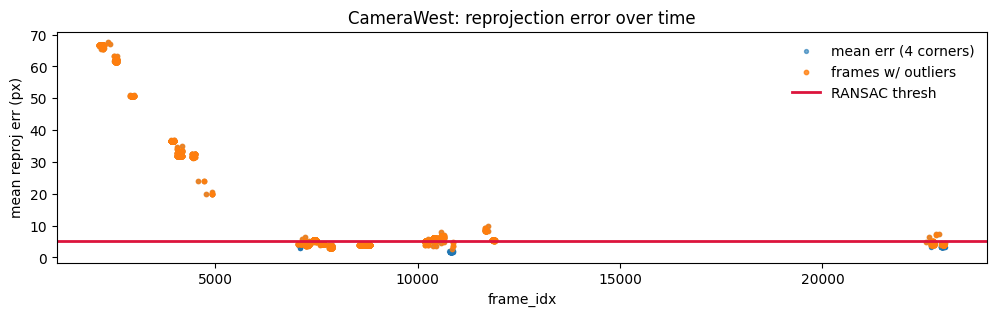

In [58]:
plt.figure(figsize=(12, 3))
plt.scatter(frames, frame_mean_err, s=8, alpha=0.6, label="mean err (4 corners)")
plt.scatter(frames[frame_n_outliers>0], frame_mean_err[frame_n_outliers>0], s=10, alpha=0.8, label="frames w/ outliers")
plt.axhline(reproj_thresh, color="crimson", linewidth=2, label="RANSAC thresh")
plt.xlabel("frame_idx")
plt.ylabel("mean reproj err (px)")
plt.title(f"{camera_side}: reprojection error over time")
plt.legend(frameon=False)
plt.show()

Top video: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi
Side video: /Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraWest/CameraWest_2026-04-14T14-00-00.avi

[1/4] frame 2242 | mean_err=66.65px max_err=71.88px outlier_corners=4/4
 per-corner errs: {'corner_1': 64.33017396492215, 'corner_2': 66.89104365059937, 'corner_3': 71.87522041069089, 'corner_4': 63.49093422192205}


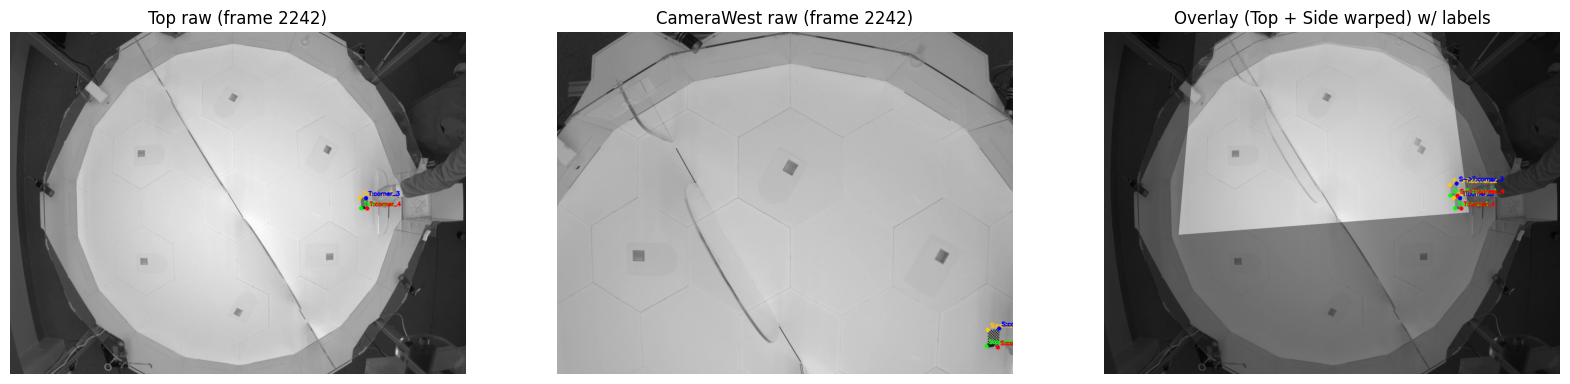


[2/4] frame 2241 | mean_err=66.66px max_err=71.80px outlier_corners=4/4
 per-corner errs: {'corner_1': 64.37084619125562, 'corner_2': 66.89228384532669, 'corner_3': 71.79500525890347, 'corner_4': 63.600310625086685}


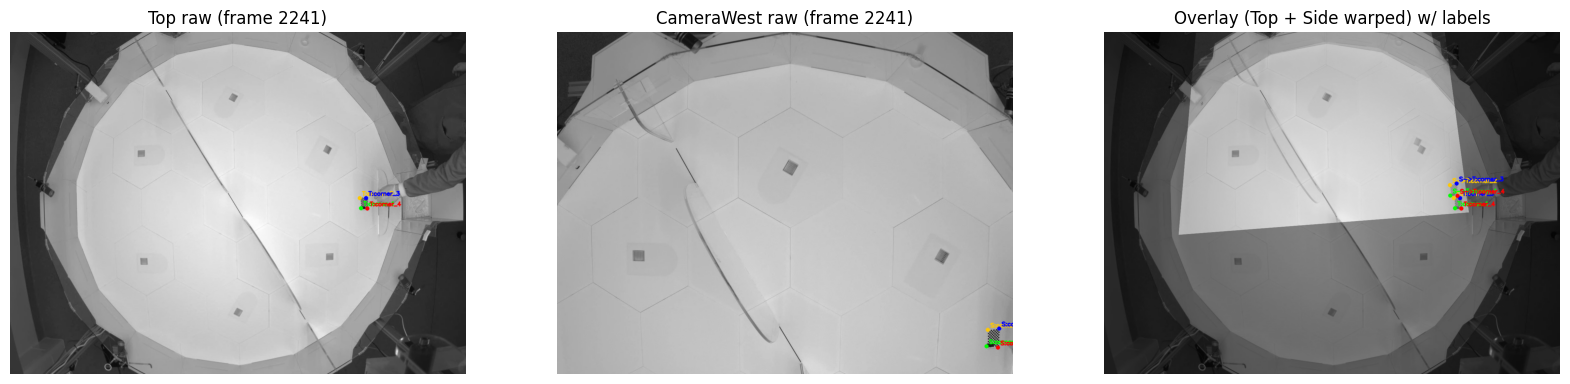


[3/4] frame 2240 | mean_err=66.65px max_err=71.65px outlier_corners=4/4
 per-corner errs: {'corner_1': 64.39871598893498, 'corner_2': 66.87743820056976, 'corner_3': 71.645118945981, 'corner_4': 63.66985532929622}


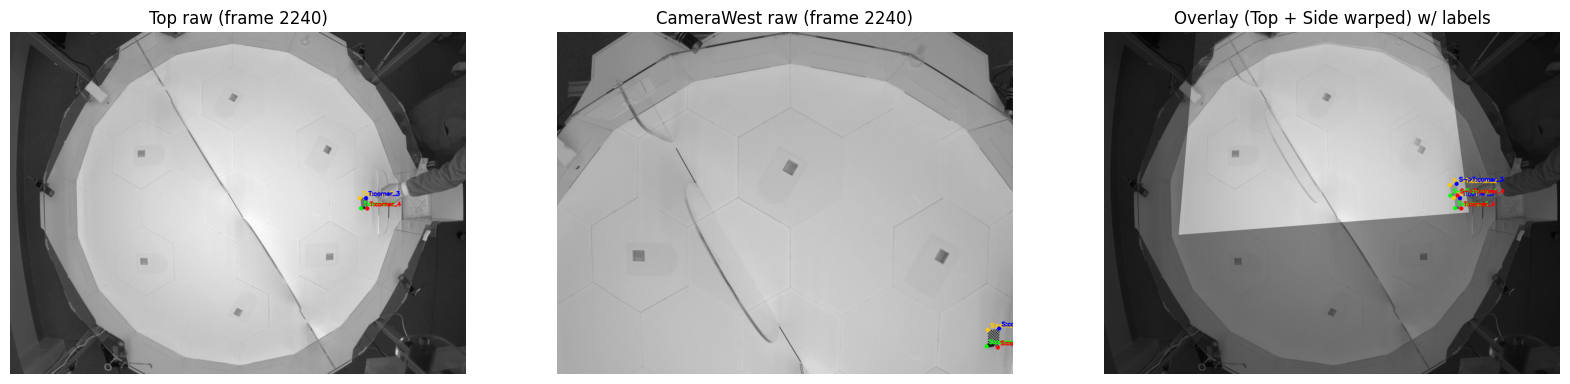


[4/4] frame 2239 | mean_err=66.64px max_err=71.58px outlier_corners=4/4
 per-corner errs: {'corner_1': 64.41914458942968, 'corner_2': 66.88306452023691, 'corner_3': 71.57747002742296, 'corner_4': 63.67678731474699}


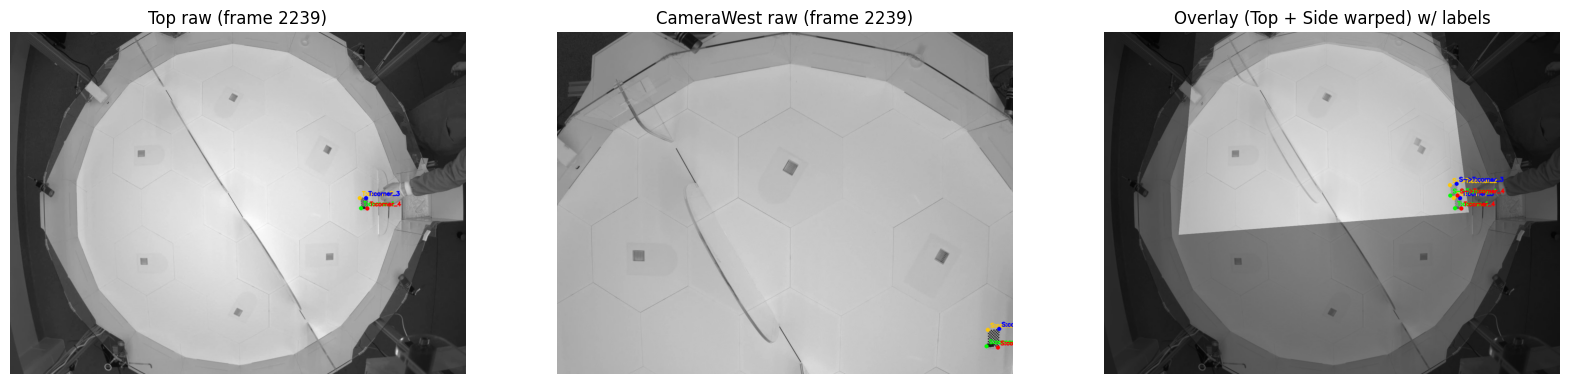

In [60]:
# Pick frames to visualize: worst by max error, but only among frames with outliers
idx_candidates = np.where(frame_n_outliers > 0)[0]
if idx_candidates.size == 0:
    raise RuntimeError("No outlier frames found under this threshold/camera.")

# Choose top K worst frames
K = 4
worst_idx = idx_candidates[np.argsort(frame_max_err[idx_candidates])[::-1][:K]]

video_top = build_video_path(raw_video_root, arena, experiment, session, chunk, "CameraTop")
video_side = build_video_path(raw_video_root, arena, experiment, session, chunk, camera_side)

print("Top video:", video_top)
print("Side video:", video_side)

for j, i in enumerate(worst_idx):
    t = int(frames[i])
    top_bgr = read_frame(video_top, t)
    side_bgr = read_frame(video_side, t)

    # corner points
    top4 = top_pts[i]   # (4,2) in Top coords
    side4 = side_pts[i] # (4,2) in Side coords

    # Warp side -> top for overlay
    top_h, top_w = top_bgr.shape[:2]
    warped_side_bgr = cv2.warpPerspective(side_bgr, H_side_to_top, (top_w, top_h))
    overlay_bgr = cv2.addWeighted(top_bgr, 0.55, warped_side_bgr, 0.45, 0)

    # Warp side corner points into Top coords
    side4_warped = cv2.perspectiveTransform(side4[None, :, :], H_side_to_top)[0]

    # Draw labeled corners
    top_labeled = draw_labeled_corners_bgr(top_bgr, top4, prefix="T:")
    side_labeled = draw_labeled_corners_bgr(side_bgr, side4, prefix="S:")
    overlay_labeled = draw_labeled_corners_bgr(overlay_bgr, top4, prefix="T:")
    overlay_labeled = draw_labeled_corners_bgr(overlay_labeled, side4_warped, prefix="S->T:")

    # Print numeric diagnostics for this frame
    print(f"\n[{j+1}/{K}] frame {t} | mean_err={frame_mean_err[i]:.2f}px max_err={frame_max_err[i]:.2f}px outlier_corners={int(frame_n_outliers[i])}/4")
    print(" per-corner errs:", {NODE_ORDER[k]: float(errs_f4[i, k]) for k in range(4)})

    # Plot
    plt.figure(figsize=(20, 8))
    plt.subplot(1, 3, 1); plt.title(f"Top raw (frame {t})"); plt.imshow(bgr_to_rgb(top_labeled)); plt.axis("off")
    plt.subplot(1, 3, 2); plt.title(f"{camera_side} raw (frame {t})"); plt.imshow(bgr_to_rgb(side_labeled)); plt.axis("off")
    plt.subplot(1, 3, 3); plt.title("Overlay (Top + Side warped) w/ labels"); plt.imshow(bgr_to_rgb(overlay_labeled)); plt.axis("off")
    plt.show()

### Generating heatmap of reprojection errors to better understand where issues arise

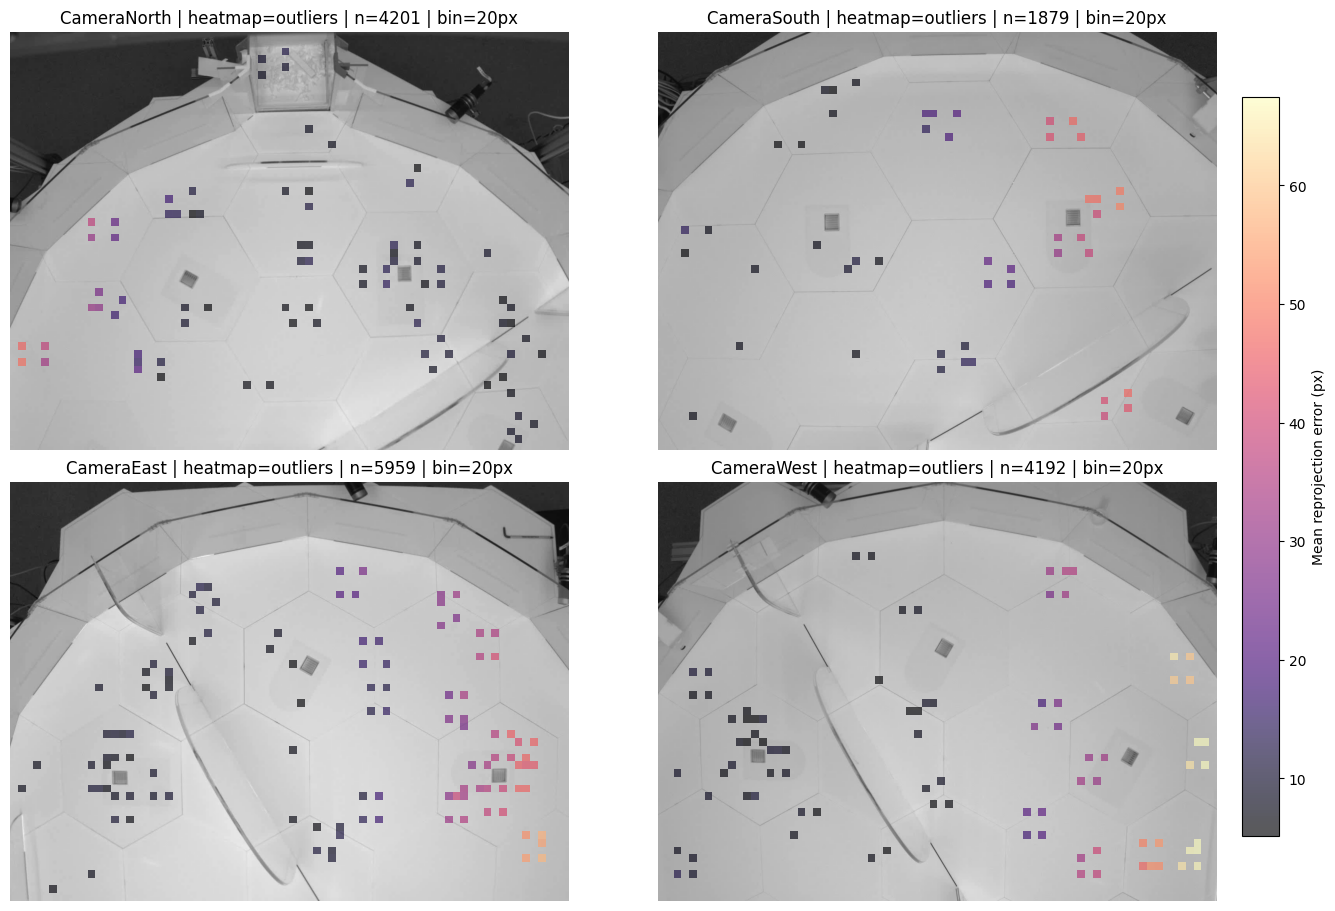

In [63]:
def _mean_error_heatmap(
    xy: np.ndarray,
    err: np.ndarray,
    img_wh: tuple[int, int],
    bin_px: int = 25,
):
    """
    xy: (N,2) points in image coords
    err: (N,) reprojection errors
    Returns:
      mean_err_map: (H_bins, W_bins) mean error per bin (NaN where empty)
      count_map:    (H_bins, W_bins) count per bin
      extent:       for imshow
    """
    w, h = img_wh
    x = xy[:, 0]
    y = xy[:, 1]

    # keep points inside image
    m = (x >= 0) & (x < w) & (y >= 0) & (y < h) & np.isfinite(err)
    x = x[m]
    y = y[m]
    e = err[m]

    if x.size == 0:
        nbx = max(1, int(np.ceil(w / bin_px)))
        nby = max(1, int(np.ceil(h / bin_px)))
        mean_map = np.full((nby, nbx), np.nan, dtype=float)
        cnt_map = np.zeros((nby, nbx), dtype=float)
        extent = (0, w, h, 0)
        return mean_map, cnt_map, extent

    x_edges = np.arange(0, w + bin_px, bin_px)
    y_edges = np.arange(0, h + bin_px, bin_px)

    # histogram2d returns shape (len(x_edges)-1, len(y_edges)-1) but with x/y ordering
    # We'll build counts and sum-errors then transpose to (y_bins, x_bins) for imshow.
    cnt, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    sume, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], weights=e)

    cnt = cnt.T
    sume = sume.T

    with np.errstate(divide="ignore", invalid="ignore"):
        mean_map = sume / cnt
        mean_map[cnt == 0] = np.nan

    extent = (0, w, h, 0)  # left, right, bottom, top for origin='upper'
    return mean_map, cnt, extent


def plot_reprojection_error_heatmaps(
    MAP_PATH: Path,
    H_by_cam: dict,
    inliers_by_cam: dict,
    side_cameras: list[str],
    arena: str,
    experiment: str,
    session: str,
    chunk: str,
    raw_video_root: Path = Path("/Volumes/aeon/aeon/data/raw"),
    frame_idx: int = 0,
    bin_px: int = 25,
    show: str = "outliers",  # "outliers" or "all" or "inliers"
    outlier_thresh_px: float | None = None,  # if None, uses ransac_reproj_threshold_px
    cmap: str = "magma",
):
    """
    Overlays mean reprojection error heatmap onto each side camera frame.
    Uses correspondences from MAP_PATH and H_by_cam from this notebook.

    show:
      - "outliers": plot only correspondences with (error > threshold) OR (inlier_mask==False)
      - "inliers":  plot only inlier correspondences
      - "all":      plot all correspondences
    """
    z = np.load(MAP_PATH)
    if outlier_thresh_px is None:
        outlier_thresh_px = float(ransac_reproj_threshold_px)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    axes = axes.ravel()

    # global color scaling across cameras (helps compare)
    vmins, vmaxs = [], []

    # first pass compute maps
    per_cam = {}
    for cam in side_cameras:
        frames = z[f"{cam}__frames"]
        top_pts = z[f"{cam}__top_pts"]
        side_pts = z[f"{cam}__side_pts"]

        src = stack_corner_points(top_pts)   # (4N,2) in Top coords
        dst = stack_corner_points(side_pts)  # (4N,2) in Side coords

        H = H_by_cam[cam]
        errs = reprojection_errors_px(H, src, dst)  # (4N,)

        inlier_mask = inliers_by_cam[cam].ravel().astype(bool)

        if show == "outliers":
            mask = (~inlier_mask) | (errs > outlier_thresh_px)
        elif show == "inliers":
            mask = inlier_mask
        elif show == "all":
            mask = np.ones_like(inlier_mask, dtype=bool)
        else:
            raise ValueError("show must be 'outliers', 'inliers', or 'all'")

        # side image size
        video_path = build_video_path(raw_video_root, arena, experiment, session, chunk, cam)
        frame_bgr = read_frame(video_path, frame_idx=frame_idx)
        h, w = frame_bgr.shape[:2]

        mean_map, cnt_map, extent = _mean_error_heatmap(dst[mask], errs[mask], (w, h), bin_px=bin_px)

        per_cam[cam] = {
            "frame_rgb": bgr_to_rgb(frame_bgr),
            "mean_map": mean_map,
            "cnt_map": cnt_map,
            "extent": extent,
            "w": w,
            "h": h,
            "errs": errs,
            "mask": mask,
        }

        if np.isfinite(mean_map).any():
            vmins.append(np.nanpercentile(mean_map, 5))
            vmaxs.append(np.nanpercentile(mean_map, 95))

    # choose shared color range
    if vmins and vmaxs:
        vmin = float(np.nanmin(vmins))
        vmax = float(np.nanmax(vmaxs))
        if vmax <= vmin:
            vmax = vmin + 1e-6
    else:
        vmin, vmax = 0.0, float(outlier_thresh_px)

    # second pass plot
    for ax, cam in zip(axes, side_cameras):
        d = per_cam[cam]
        ax.imshow(d["frame_rgb"])
        hm = ax.imshow(
            d["mean_map"],
            extent=d["extent"],
            origin="upper",
            cmap=cmap,
            alpha=0.65,
            vmin=vmin,
            vmax=vmax,
        )
        n = int(np.sum(d["mask"]))
        ax.set_title(f"{cam} | heatmap={show} | n={n} | bin={bin_px}px")
        ax.axis("off")

    cbar = fig.colorbar(hm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("Mean reprojection error (px)")

    return fig

raw_video_root = Path("/Volumes/aeon/aeon/data/raw")

fig = plot_reprojection_error_heatmaps(
    MAP_PATH=MAP_PATH,
    H_by_cam=H_by_cam,
    inliers_by_cam=inliers_by_cam,
    side_cameras=side_cameras,
    arena=arena,
    experiment=experiment,
    session=session,
    chunk=chunk,
    raw_video_root=raw_video_root,
    frame_idx=0,
    bin_px=20,
    show="outliers",                 # <- most useful to see where failures happen
    outlier_thresh_px=ransac_reproj_threshold_px,
    cmap="magma",
)
plt.show()